In [1]:
import tensorflow as tf
import keras
from keras.datasets import mnist
from keras.models import Sequential
from keras.layers import Dense, Dropout,Flatten, Conv2D, MaxPooling2D
from keras import backend as K  

#load data
(x_train, y_train), (x_test, y_test) = mnist.load_data()

# Reshape input data to inclue the channel dimension
x_train = x_train.reshape(x_train.shape[0], 28, 28, 1).astype('float32') / 255
x_test = x_test.reshape(x_test.shape[0], 28, 28, 1).astype('float32') / 255

# convert labels to one-hot encoding
y_train = keras.utils.to_categorical(y_train, 10)
y_test = keras.utils.to_categorical(y_test, 10)


11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


In [2]:
def build_model(optimizer):
    model = Sequential()
    model.add(Conv2D(32, kernel_size=(3, 3), activation='relu', input_shape=(28, 28, 1)))
    model.add(MaxPooling2D(pool_size=(2, 2)))
    model.add(Dropout(0.25))
    model.add(Flatten())
    model.add(Dense(256, activation='relu'))
    model.add(Dropout(0.5))
    model.add(Dense(10, activation='softmax'))

    model.compile(loss='categorical_crossentropy', optimizer=optimizer,metrics=[
        'accuracy'])
    
    return model


In [4]:
optimizers = ['Adadelta','SGD', 'Adam', 'RMsprop', 'Adagrad' ]
history_dic = {}

for opt in optimizers:
    print("Training with {}".format(opt))
    model = build_model(opt)
    history = model.fit(x_train, y_train,
              batch_size=64,
              epochs=10,
              verbose=1,
              validation_data=(x_test, y_test))
    history_dic[opt]=history



Training with Adadelta


/workspaces/AI-NN/.venv/lib/python3.13/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 35s 36ms/step - accuracy: 0.1655 - loss: 2.2532 - val_accuracy: 0.4199 - val_loss: 2.1731
Epoch 2/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 34s 36ms/step - accuracy: 0.3443 - loss: 2.1275 - val_accuracy: 0.6488 - val_loss: 2.0255
Epoch 3/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 34s 36ms/step - accuracy: 0.4955 - loss: 1.9848 - val_accuracy: 0.7129 - val_loss: 1.8586
Epoch 4/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 32s 34ms/step - accuracy: 0.5820 - loss: 1.8264 - val_accuracy: 0.7524 - val_loss: 1.6797
Epoch 5/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 33s 35ms/step - accuracy: 0.6377 - loss: 1.6611 - val_accuracy: 0.7832 - val_loss: 1.5011
Epoch 6/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 33s 35ms/step - accuracy: 0.6729 - loss: 1.5015 - val_accuracy: 0.8022 - val_loss: 1.3327
Epoch 7/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 33s 35ms/step - accuracy: 0.6978 - loss: 1.3555 - val_accuracy: 0.8168 - val_loss: 1.1830
Epoch 8/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 41s 35ms/step - accuracy: 0.7165 - loss: 1.2287 - 

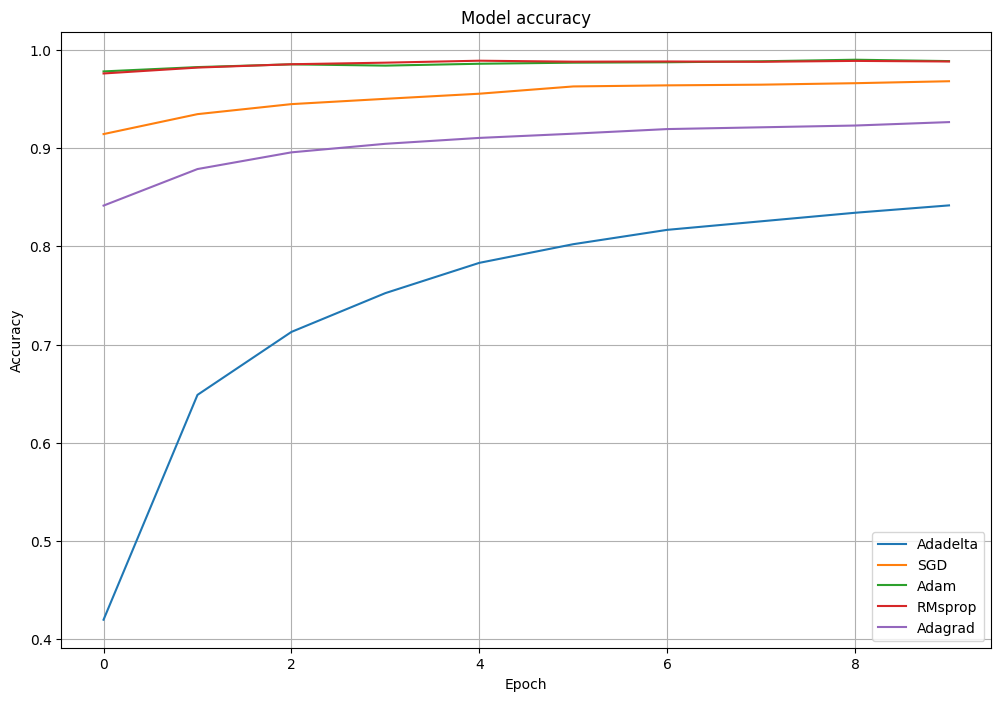

In [5]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 8))
for opt in optimizers:
    plt.plot(history_dic[opt].history['val_accuracy'], label=opt)

plt.title('Model accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend()
plt.grid(True)
plt.show()
